# Customer Classification Project

## Business Problem
The Marketing and Sales Director of **BFLUBS** wants to segment the customer base into **five new divisions** using **data science**. This segmentation is based on the **geolocation of customers**, aiming for better organization and more effective commercial strategies.

In addition, an **automated methodology** was developed to classify new customers into the correct divisions using **artificial intelligence**, ensuring a precise and efficient allocation.

## Approach
1. **Unsupervised Machine Learning** — KMeans clustering to create the 5 customer divisions based on latitude and longitude
2. **Supervised Machine Learning** — Decision Tree Classifier trained on the clusters to predict which division new customers belong to

# Importing Data

In [1]:
# Importing libraries

import pandas as pd
import folium
import matplotlib.pyplot as plt 
import sklearn

In [2]:
# Importing the dataset customers

customers = pd.read_csv('ProjetoClassificaçãoClientes/dados/tbl_customers.csv', encoding='utf-8')
customers = customers[['id_customer', 'ds_customer', 'id_location','sales_manager']]
customers.head()

,id_customer,ds_customer,id_location,sales_manager
0,2431,Customer 2431,LOTX00474,James Miller
1,2434,Customer 2434,LOIL00475,Angela Thompson
2,2437,Customer 2437,LOIL00476,Angela Thompson
3,2440,Customer 2440,LOMO00487,Angela Thompson
4,2443,Customer 2443,LOMO00488,Angela Thompson


In [3]:
# Importing location dataset

locations = pd.read_csv('ProjetoClassificaçãoClientes/dados/tbl_locations.csv', encoding='utf-8')
locations.head()

,id_location,id_country,id_state,ds_city,latitude,longitude,division,regional
0,LOTX00474,US,TX,Austin,29.924724,-96.729571,South/Southeast,Southeast
1,LOIL00475,US,IL,Springfield,41.139196,-88.940805,Central/Northeast,Great Lakes
2,LOIL00476,US,IL,Rockford,40.793611,-89.206403,Central/Northeast,Great Lakes
3,LOMO00487,US,MO,Kansas City,38.234850,-91.780294,Central/Northeast,Midwest
4,LOMO00488,US,MO,St. Louis,38.560669,-91.875156,Central/Northeast,Midwest


In [4]:
# Importing plants dataset

plants = pd.read_csv('ProjetoClassificaçãoClientes/dados/tbl_plants.csv', encoding='utf-8')
plants.head()

,id_plant,ds_plant,id_country,id_state,ds_city,latitude,longitude,plant_manager
0,CA001,Los Angeles,US,CA,Los Angeles,34.052235,-118.243683,Michael Carter
1,TX012,Houston,US,TX,Houston,29.760427,-95.369804,Sandra Williams
2,NY023,New York,US,NY,New York City,40.712776,-74.005974,James Thompson
3,IL034,Chicago,US,IL,Chicago,41.878113,-87.629799,Patricia Moore
4,FL045,Miami,US,FL,Miami,25.774173,-80.190262,Robert Davis


In [5]:
# Combining customers and locations

customers = customers.merge(
    locations,
    how='inner',
    on='id_location'
)
customers.head()

,id_customer,ds_customer,id_location,sales_manager,id_country,id_state,ds_city,latitude,longitude,division,regional
0,2431,Customer 2431,LOTX00474,James Miller,US,TX,Austin,29.924724,-96.729571,South/Southeast,Southeast
1,2434,Customer 2434,LOIL00475,Angela Thompson,US,IL,Springfield,41.139196,-88.940805,Central/Northeast,Great Lakes
2,2437,Customer 2437,LOIL00476,Angela Thompson,US,IL,Rockford,40.793611,-89.206403,Central/Northeast,Great Lakes
3,2440,Customer 2440,LOMO00487,Angela Thompson,US,MO,Kansas City,38.234850,-91.780294,Central/Northeast,Midwest
4,2443,Customer 2443,LOMO00488,Angela Thompson,US,MO,St. Louis,38.560669,-91.875156,Central/Northeast,Midwest


# Customer Visualization

In [35]:
# Visualizing customers on the map
customer_map = folium.Map(
    location=[customers['latitude'].mean(), customers['longitude'].mean()],
    zoom_start = 4
)

# Adding markers to the map
for index, row in customers.iterrows():
    folium.CircleMarker(
        location = [row['latitude'], row['longitude']],
        popup = row['ds_customer'],
        radius = 5,
        color = 'blue',
        fill_color = 'blue',
        opacity = 0.7
    ).add_to(customer_map)

# Adding the plants to the map
for index, row in plants.iterrows():
    folium.Marker(
        location = [row['latitude'], row['longitude']],
        popup = row['ds_plant'],
        icon = folium.Icon(color='red', icon='industry', prefix='fa')
    ).add_to(customer_map)

# Displaying the map
customer_map.save('customer_map.html')
customer_map

# Classifying Customers

## Unsupervised Machine Learning

In [7]:
# Importing KMeans from sklearn
from sklearn.cluster import KMeans

# Defining the number of clusters
number_clusters = 5

# Selecting the coordinates for clustering and creating a new dataframe
X = customers[['latitude', 'longitude']]

# Applying KMeans
kmeans = KMeans(n_clusters=number_clusters, random_state=42, n_init=10)
customers['division_cluster'] = kmeans.fit_predict(X)
customers.head()

,id_customer,ds_customer,id_location,sales_manager,id_country,id_state,ds_city,latitude,longitude,division,regional,division_cluster
0,2431,Customer 2431,LOTX00474,James Miller,US,TX,Austin,29.924724,-96.729571,South/Southeast,Southeast,3
1,2434,Customer 2434,LOIL00475,Angela Thompson,US,IL,Springfield,41.139196,-88.940805,Central/Northeast,Great Lakes,0
2,2437,Customer 2437,LOIL00476,Angela Thompson,US,IL,Rockford,40.793611,-89.206403,Central/Northeast,Great Lakes,0
3,2440,Customer 2440,LOMO00487,Angela Thompson,US,MO,Kansas City,38.234850,-91.780294,Central/Northeast,Midwest,0
4,2443,Customer 2443,LOMO00488,Angela Thompson,US,MO,St. Louis,38.560669,-91.875156,Central/Northeast,Midwest,0


## Visualizing New Clusters

In [36]:
# Visualizing customers on the map
customer_map = folium.Map(
    location=[customers['latitude'].mean(), customers['longitude'].mean()],
    zoom_start = 4
)

# Defining colors for clusters
colors = ['blue', 'red', 'green', 'orange', 'black']

# Adding markers to the map
for index, row in customers.iterrows():
    folium.CircleMarker(
        location = [row['latitude'], row['longitude']],
        popup = row['ds_customer'],
        radius = 5,
        color = colors[row['division_cluster']],
        fill_color = colors[row['division_cluster']],
        opacity = 0.7
    ).add_to(customer_map)

# # Adding the plants to the map
for index, row in plants.iterrows():
    folium.Marker(
        location = [row['latitude'], row['longitude']],
        popup = row['ds_plant'],
        icon = folium.Icon(color='red', icon='industry', prefix='fa')
    ).add_to(customer_map)

# Displaying the map
customer_map.save('customer_clusters_map.html')
customer_map

## Identifying the Ideal Number of Clusters

#### The Elbow Method is a technique used to find the best number of clusters when working with the K-Means algorithm. By plotting how inertia changes as we increase the number of groups, we can identify the point where adding more clusters no longer provides a significant improvement — that "elbow" point is typically the optimal choice.

### Why 5 Clusters?
Based on the Elbow Method chart below, the curve shows a sharp drop between 1 and 2 clusters, and begins to flatten out around 3 to 5. Combined with the geographic spread of customers across the United States and the 7 plant locations, **5 clusters** was selected as the optimal number — providing a meaningful and balanced commercial segmentation.

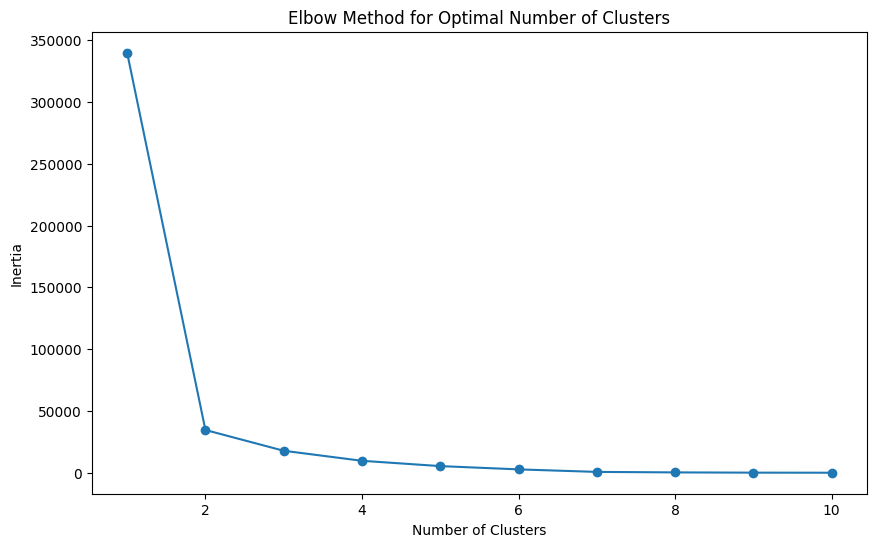

In [9]:
# Elbow method to determine the optimal number of clusters
clusters_range = range(1, 11)
inertia_values = []

# Applying KMeans for each number of clusters and storing the inertia values
for k in clusters_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(customers[['latitude', 'longitude']])
    inertia_values.append(kmeans.inertia_)

# Plotting the Elbow method results
plt.figure(figsize=(10, 6))
plt.plot(clusters_range, inertia_values, marker='o', linestyle='-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()


### Why a Decision Tree Classifier?
After defining the customer divisions with KMeans, a **Decision Tree Classifier** was chosen to automate the classification of new customers because:
- It is easy to interpret and explain to non-technical stakeholders
- It works well with geographic coordinate data
- It allows the business to classify future customers instantly based on their location

## Train the Model and Predict New Customers

In [32]:
# Importing the libraries from SKLearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Preparing the data for classification
X  = customers[['latitude', 'longitude']]
y = customers['division_cluster']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the Decision Tree Classifier
classifier = DecisionTreeClassifier(random_state=42, max_depth=5)
classifier.fit(X_train, y_train)

# Predicting the clusters for the test set
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_pred, y_test)
print(f'Accuracy: {accuracy:.2%}')


# Adding new customers to classify
new_customers = pd.DataFrame({
    'latitude':  [40.7128,   34.0522,    41.8781,    29.7604,    33.4484],
    'longitude': [-74.0060,  -118.2437,  -87.6298,   -95.3698,   -112.0740]
})
new_customers['ds_customer'] = ['Customer A', 'Customer B', 'Customer C', 'Customer D', 'Customer E']

division_prediction = classifier.predict(new_customers[['latitude', 'longitude']])
new_customers['division_cluster'] = division_prediction

print("-----------------------------------------------------")
print(new_customers[['ds_customer', 'latitude', 'longitude', 'division_cluster']])


Accuracy: 100.00%
-----------------------------------------------------
  ds_customer  latitude  longitude  division_cluster
0  Customer A   40.7128   -74.0060                 2
1  Customer B   34.0522  -118.2437                 1
2  Customer C   41.8781   -87.6298                 0
3  Customer D   29.7604   -95.3698                 3
4  Customer E   33.4484  -112.0740                 1


# Final Considerations

In this study, I applied unsupervised machine learning techniques to group customers based on their latitude and longitude. This approach made it possible to detect geographic patterns and organize the customer base into meaningful segments.

Once the clusters were established, a supervised machine learning model was trained to predict which division new customers belong to, using their geographic coordinates as input. This allows future customers to be automatically placed into the correct group without any manual work.

This methodology gives the company a structured and scalable way to manage customer segmentation, ultimately supporting better and more informed strategic decisions.

## Conclusion

This project successfully demonstrated how **data science and machine learning** can be applied to solve a real business problem — customer segmentation.

- **KMeans** was used to create 5 geographic divisions from scratch
- A **Decision Tree Classifier** was trained achieving **100% accuracy** on the test set
- New customers can now be **automatically classified** into the correct division based on their location

This solution is scalable, easy to maintain, and can be directly integrated into the company's commercial strategy.